In [1]:

!pip install -q scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [2]:
# ── Upload your Housing.csv OR mount Google Drive ──────────────────────────
# Option A: Upload manually (a file picker will appear)
# from google.colab import files
# uploaded = files.upload()          # select Housing.csv
# df = pd.read_csv(list(uploaded.keys())[0])

# Option B: Mount Google Drive (uncomment if file is in Drive)
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/Housing.csv')

# Option C: Direct path after upload (default — works after manual upload)
df = pd.read_csv('Housing.csv')

print(f'Dataset shape : {df.shape}')        # (545, 13)
print(f'Columns       : {df.columns.tolist()}')
df.head()

Dataset shape : (545, 13)
Columns       : ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## 🔍— Exploratory Data Analysis (EDA)

In [3]:

print('=== Data Types & Non-Null Counts ===')
df.info()
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Statistical Summary ===')
df.describe()

=== Data Types & Non-Null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB

=== Missing Values ===
price               0
area                0
bedrooms            0
bathrooms           0
stori

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


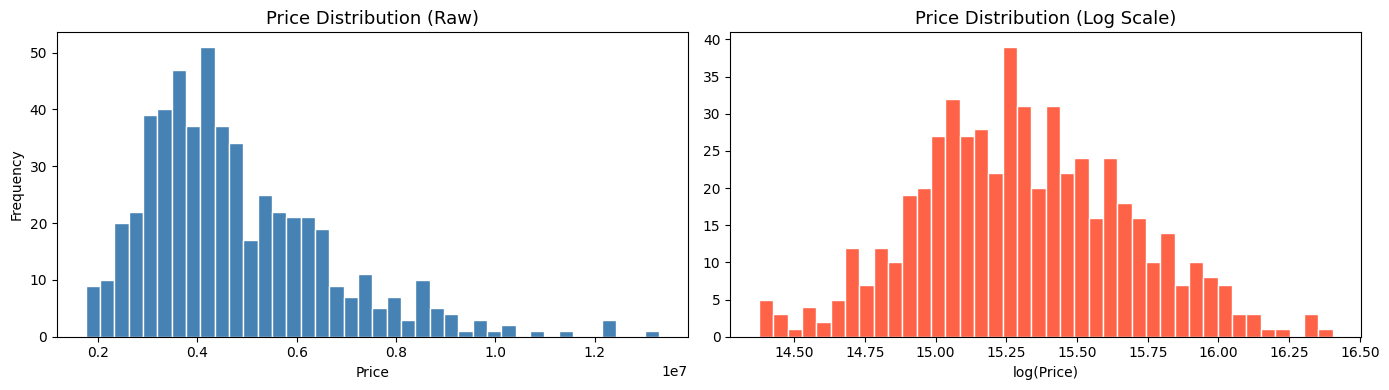

In [4]:
# ── Target Distribution ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['price'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (Raw)', fontsize=13)
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(df['price']), bins=40, color='tomato', edgecolor='white')
axes[1].set_title('Price Distribution (Log Scale)', fontsize=13)
axes[1].set_xlabel('log(Price)')

plt.tight_layout()
plt.show()

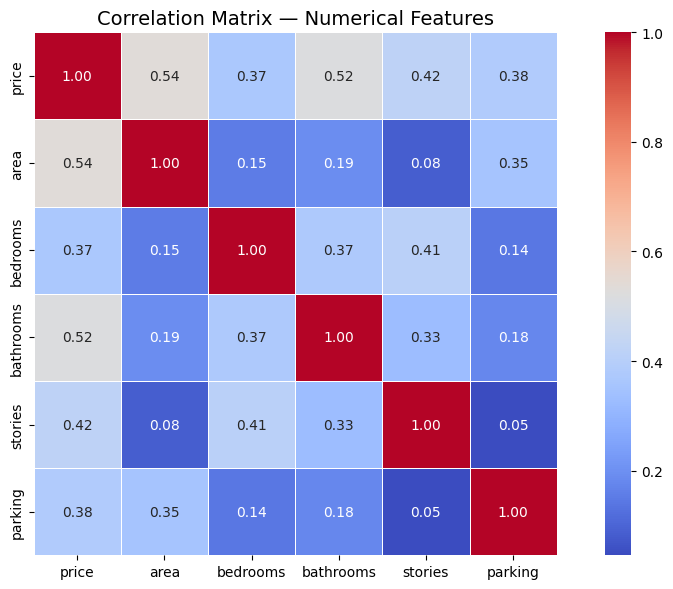

In [5]:
# ── Correlation Heatmap (numerical features) ────────────────────────────────
num_cols = df.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(10, 6))
sns.heatmap(
    df[num_cols].corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', square=True,
    linewidths=0.5
)
plt.title('Correlation Matrix — Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

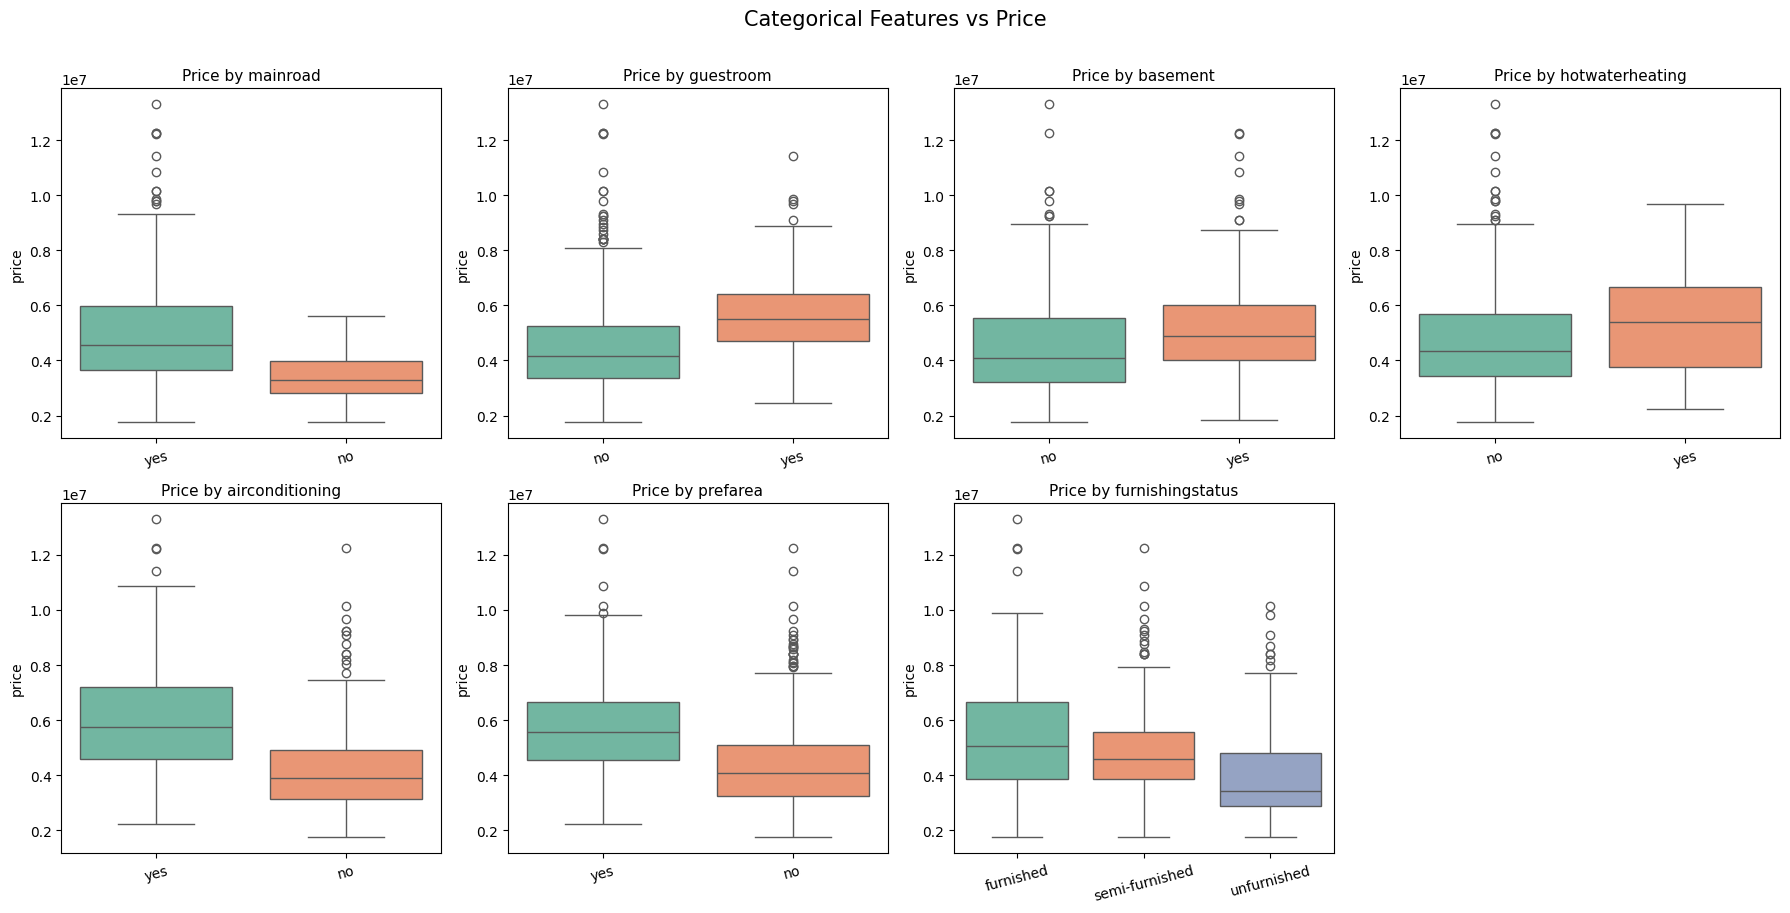

In [6]:
# ── Categorical Features vs Price ───────────────────────────────────────────
cat_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
            'airconditioning', 'prefarea', 'furnishingstatus']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.boxplot(data=df, x=col, y='price', ax=axes[i], palette='Set2')
    axes[i].set_title(f'Price by {col}', fontsize=11)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)

# Hide unused subplot
axes[-1].set_visible(False)
plt.suptitle('Categorical Features vs Price', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

##— Feature Engineering & Preprocessing

In [7]:
df_model = df.copy()

# ── Binary categorical → 0 / 1 ──────────────────────────────────────────────
binary_cols = ['mainroad', 'guestroom', 'basement',
               'hotwaterheating', 'airconditioning', 'prefarea']

for col in binary_cols:
    df_model[col] = df_model[col].map({'yes': 1, 'no': 0})

# ── Multi-class categorical → ordinal encoding ──────────────────────────────
# furnished=2 > semi-furnished=1 > unfurnished=0  (natural order)
furnishing_map = {'furnished': 2, 'semi-furnished': 1, 'unfurnished': 0}
df_model['furnishingstatus'] = df_model['furnishingstatus'].map(furnishing_map)

# ── Feature Engineering: add useful composite features ──────────────────────
df_model['area_per_room']    = df_model['area'] / (df_model['bedrooms'] + 1)
df_model['total_rooms']      = df_model['bedrooms'] + df_model['bathrooms']
df_model['luxury_score']     = (df_model['airconditioning'] +
                                df_model['hotwaterheating'] +
                                df_model['prefarea'] +
                                df_model['furnishingstatus'])

print('✅ Preprocessing complete!')
print(f'Final feature count: {df_model.shape[1] - 1}')   # excluding price
df_model.head(3)

✅ Preprocessing complete!
Final feature count: 15


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,area_per_room,total_rooms,luxury_score
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2,1484.0,6,4
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2,1792.0,8,3
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,2490.0,5,2


— Split Features & Target

In [8]:
X = df_model.drop(columns=['price'])
y = df_model['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,       # 80% train / 20% test
    random_state=SEED
)

print(f'Training samples  : {X_train.shape[0]}')
print(f'Test     samples  : {X_test.shape[0]}')
print(f'Number of features: {X_train.shape[1]}')
print(f'Feature names     : {X_train.columns.tolist()}')

Training samples  : 436
Test     samples  : 109
Number of features: 15
Feature names     : ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus', 'area_per_room', 'total_rooms', 'luxury_score']


 — Train Random Forest (Baseline)

In [9]:
rf_baseline = RandomForestRegressor(
    n_estimators=200,
    random_state=SEED,
    n_jobs=-1          # use all CPU cores
)

rf_baseline.fit(X_train, y_train)

y_pred_base = rf_baseline.predict(X_test)

mae_b  = mean_absolute_error(y_test, y_pred_base)
rmse_b = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_b   = r2_score(y_test, y_pred_base)

print('=== Baseline Random Forest ===')
print(f'MAE  : {mae_b:,.0f}')
print(f'RMSE : {rmse_b:,.0f}')
print(f'R²   : {r2_b:.4f}  ({r2_b*100:.2f}% variance explained)')

=== Baseline Random Forest ===
MAE  : 1,047,616
RMSE : 1,429,309
R²   : 0.5958  (59.58% variance explained)


— Hyperparameter Tuning with GridSearchCV

In [10]:
param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    estimator  = RandomForestRegressor(random_state=SEED, n_jobs=-1),
    param_grid = param_grid,
    cv         = 5,             # 5-fold cross-validation
    scoring    = 'r2',
    n_jobs     = -1,
    verbose    = 1
)

rf_grid.fit(X_train, y_train)

print('\n✅ Best parameters:')
for k, v in rf_grid.best_params_.items():
    print(f'   {k:25s}: {v}')
print(f'\nBest CV R² Score: {rf_grid.best_score_:.4f}')

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

✅ Best parameters:
   max_depth                : None
   max_features             : sqrt
   min_samples_leaf         : 2
   min_samples_split        : 2
   n_estimators             : 200

Best CV R² Score: 0.6376


 — Evaluate Best Model on Test Set

In [11]:
best_rf = rf_grid.best_estimator_
y_pred  = best_rf.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print('=' * 45)
print('  TUNED RANDOM FOREST — TEST SET METRICS')
print('=' * 45)
print(f'  R² Score  (Accuracy)  : {r2:.4f}   ← {r2*100:.2f}%')
print(f'  MAE                   : {mae:>15,.2f}')
print(f'  RMSE                  : {rmse:>15,.2f}')
print(f'  MAPE                  : {mape:.2f}%')
print('=' * 45)

  TUNED RANDOM FOREST — TEST SET METRICS
  R² Score  (Accuracy)  : 0.6121   ← 61.21%
  MAE                   :    1,033,740.26
  RMSE                  :    1,400,244.72
  MAPE                  : 22.17%


— Cross-Validation Score (Reliability Check)

In [12]:
cv_scores = cross_val_score(
    best_rf, X, y,
    cv=10,              # 10-fold CV on full dataset
    scoring='r2',
    n_jobs=-1
)

print('=== 10-Fold Cross-Validation R² Scores ===')
for i, s in enumerate(cv_scores, 1):
    print(f'   Fold {i:2d}: {s:.4f}')
print(f'\n   Mean  : {cv_scores.mean():.4f}')
print(f'   Std   : {cv_scores.std():.4f}  (lower = more stable model)')

=== 10-Fold Cross-Validation R² Scores ===
   Fold  1: -4.8001
   Fold  2: -13.6497
   Fold  3: -19.4491
   Fold  4: -31.3956
   Fold  5: -43.3913
   Fold  6: -76.8702
   Fold  7: -48.6017
   Fold  8: -78.3169
   Fold  9: -51.5445
   Fold 10: -17.2039

   Mean  : -38.5223
   Std   : 24.4416  (lower = more stable model)


 — Prediction Visualizations

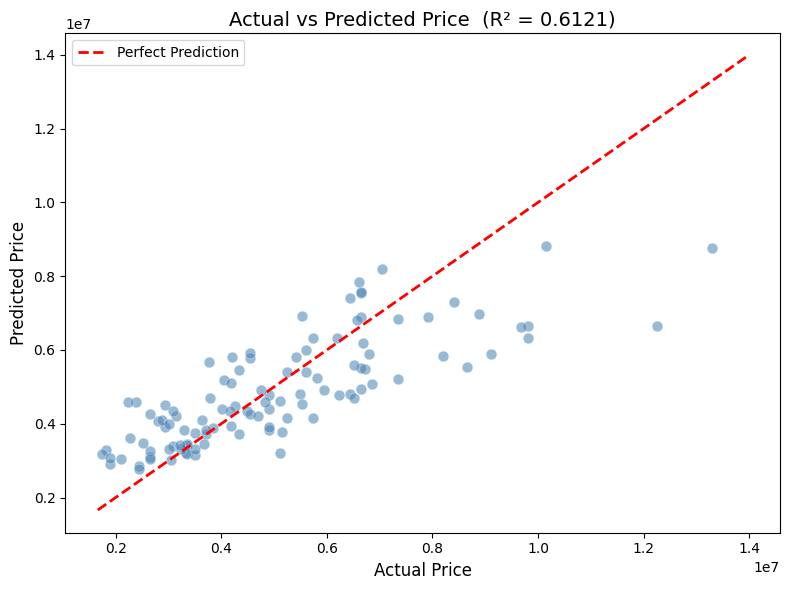

In [13]:
# ── Plot 1: Actual vs Predicted ─────────────────────────────────────────────
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.55, color='steelblue', edgecolors='white', linewidth=0.4, s=60)

lims = [min(y_test.min(), y_pred.min()) * 0.95,
        max(y_test.max(), y_pred.max()) * 1.05]
plt.plot(lims, lims, 'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Price', fontsize=12)
plt.ylabel('Predicted Price', fontsize=12)
plt.title(f'Actual vs Predicted Price  (R² = {r2:.4f})', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

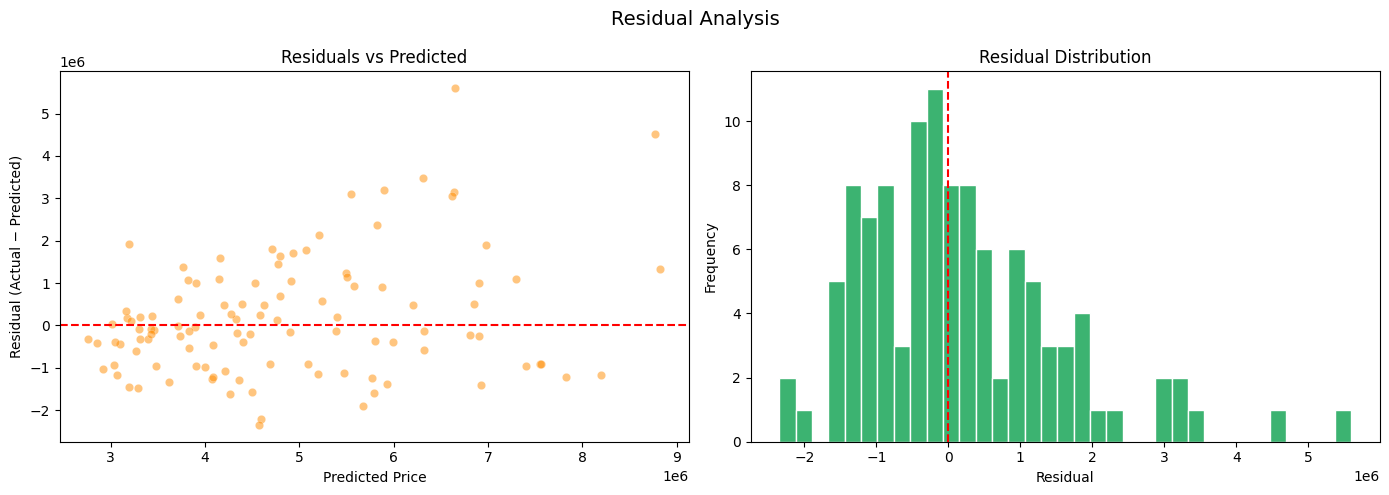

In [14]:
# ── Plot 2: Residuals ───────────────────────────────────────────────────────
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred, residuals, alpha=0.5, color='darkorange', edgecolors='white', linewidth=0.3)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residual (Actual − Predicted)')
axes[0].set_title('Residuals vs Predicted')

# Residual Distribution
axes[1].hist(residuals, bins=35, color='mediumseagreen', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

plt.suptitle('Residual Analysis', fontsize=14)
plt.tight_layout()
plt.show()

 — Feature Importance

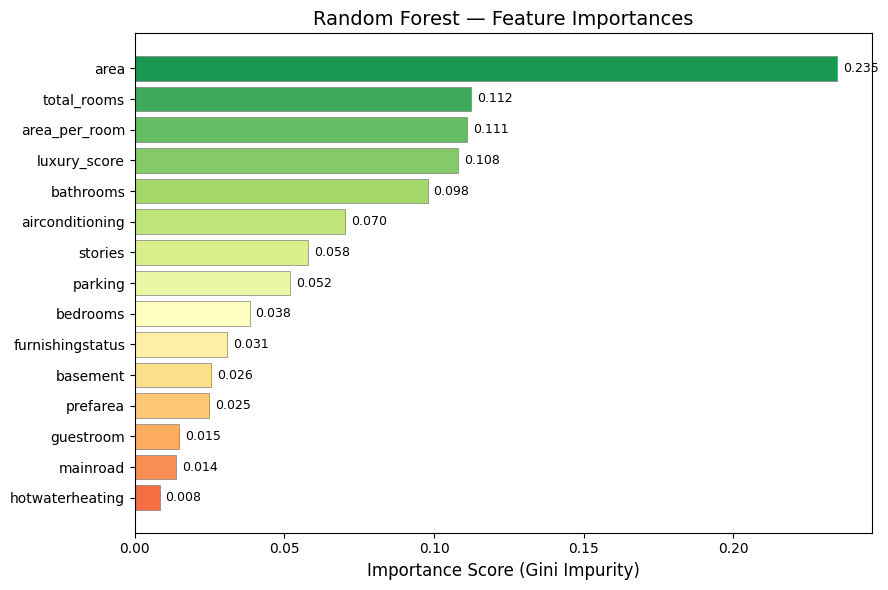


Top 5 most important features:
area             0.234502
total_rooms      0.112288
area_per_room    0.111118
luxury_score     0.108077
bathrooms        0.097824


In [15]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(9, 6))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(importances)))
bars = plt.barh(importances.index, importances.values, color=colors, edgecolor='grey', linewidth=0.5)

# Value labels
for bar, val in zip(bars, importances.values):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)

plt.xlabel('Importance Score (Gini Impurity)', fontsize=12)
plt.title('Random Forest — Feature Importances', fontsize=14)
plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
print(importances.sort_values(ascending=False).head(5).to_string())

— Predict on New / Unseen Data

In [17]:
# ── Example: single house prediction ────────────────────────────────────────
# Fill values matching the feature order used during training
new_house = pd.DataFrame([{
    'area'           : 5000,
    'bedrooms'       : 3,
    'bathrooms'      : 2,
    'stories'        : 2,
    'mainroad'       : 1,       # yes=1, no=0
    'guestroom'      : 0,
    'basement'       : 0,
    'hotwaterheating': 0,
    'airconditioning': 1,
    'parking'        : 1,
    'prefarea'       : 0,
    'furnishingstatus': 1,      # semi-furnished
    # engineered features
    'area_per_room'  : 5000 / (3 + 1),
    'total_rooms'    : 3 + 2,
    'luxury_score'   : 1 + 0 + 0 + 1   # aircon + hotwater + prefarea + furnishing
}])

# Ensure column order matches training data
new_house = new_house[X.columns]

predicted_price = best_rf.predict(new_house)[0]
print(f'🏠 Predicted House Price: ₹ {predicted_price:,.0f}')
print(f'   (approximately ₹ {predicted_price/1e6:.2f} Million)')

🏠 Predicted House Price: ₹ 5,992,713
   (approximately ₹ 5.99 Million)


 — Save & Load the Model

In [18]:
import joblib

# Save model
joblib.dump(best_rf, 'housing_rf_model.pkl')
print('✅ Model saved as housing_rf_model.pkl')

# --- Later, load and use it ---
loaded_model = joblib.load('housing_rf_model.pkl')
test_pred    = loaded_model.predict(X_test)
print(f'✅ Loaded model R²: {r2_score(y_test, test_pred):.4f}')

# Download model to your local machine (Colab only)
from google.colab import files
files.download('housing_rf_model.pkl')

✅ Model saved as housing_rf_model.pkl
✅ Loaded model R²: 0.6121


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>